<a href="https://colab.research.google.com/github/Abraham353/Laboratorio_11--MD/blob/develop/Laboratorio_11_MD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importar librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

# Leer el archivo CSV
df = pd.read_csv('Advertising-1.csv')

# Mostrar información básica
print("Primeras filas del dataset:")
print(df.head())

print("\nInformación del dataset:")
print(df.info())

print("\nEstadísticas descriptivas:")
print(df.describe())

# Análisis de datos faltantes
print("\nDatos faltantes por columna:")
print(df.isnull().sum())

Primeras filas del dataset:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Estadísticas descriptivas:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
5


Detección de outliers univariados:
Outliers en TV: 0
Outliers en Radio: 0
Outliers en Newspaper: 2
Outliers en Sales: 0


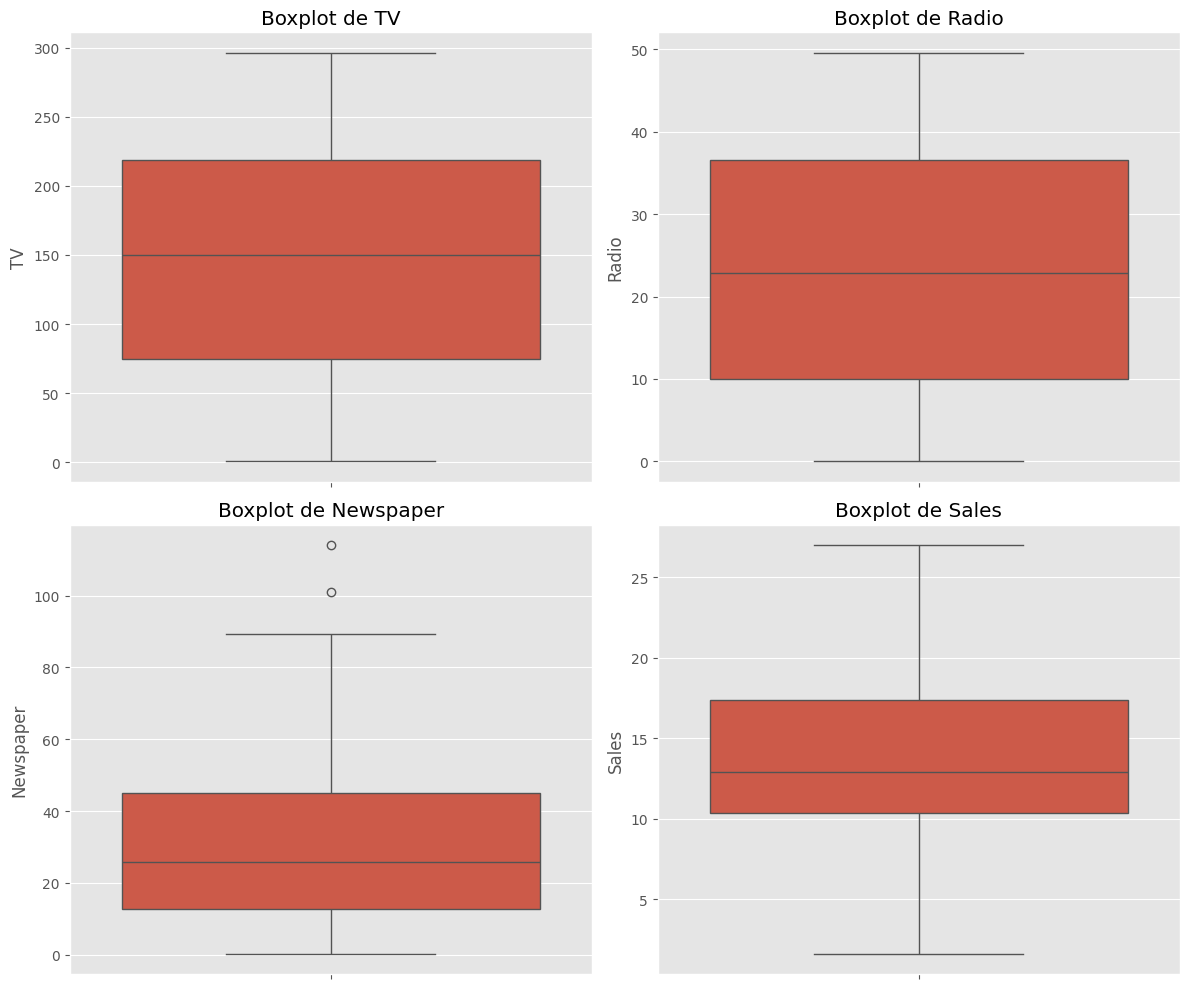


Outliers multivariados detectados: 5

Tamaño del dataset después de eliminar outliers: (195, 4)


In [3]:
# Detección de outliers univariados
def detect_outliers_univariate(data, threshold=3):
    z_scores = np.abs((data - data.mean()) / data.std())
    return z_scores > threshold

print("\nDetección de outliers univariados:")
outliers_info = {}
for column in df.columns:
    outliers = detect_outliers_univariate(df[column])
    outliers_info[column] = {
        'count': outliers.sum(),
        'indices': df[outliers].index.tolist()
    }
    print(f"Outliers en {column}: {outliers.sum()}")

# Visualización de outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, column in enumerate(df.columns):
    ax = axes[i//2, i%2]
    sns.boxplot(data=df, y=column, ax=ax)
    ax.set_title(f'Boxplot de {column}')
plt.tight_layout()
plt.show()

# Detección de outliers multivariados (distancia de Mahalanobis)
from scipy.stats import chi2

def mahalanobis_distance(x=None, data=None, cov=None):
    x_minus_mu = x - np.mean(data, axis=0)
    if not cov:
        cov = np.cov(data.T)
    inv_cov = np.linalg.inv(cov)
    left_term = np.dot(x_minus_mu, inv_cov)
    md = np.dot(left_term, x_minus_mu.T)
    return md

# Calcular distancia de Mahalanobis
X = df.drop('Sales', axis=1).values
mahalanobis_dist = np.array([mahalanobis_distance(x, X) for x in X])

# Umbral para outliers (percentil 95 de la distribución chi-cuadrado)
threshold = chi2.ppf(0.95, df.shape[1]-1)
outliers_multi = mahalanobis_dist > threshold

print(f"\nOutliers multivariados detectados: {outliers_multi.sum()}")

# Eliminar outliers multivariados
df_clean = df[~outliers_multi].copy()
print(f"\nTamaño del dataset después de eliminar outliers: {df_clean.shape}")


Primeras filas de datos escalados:
   TV_scaled  Radio_scaled  Newspaper_scaled  Sales
0   0.975464      1.008429          2.071434   22.1
1  -1.219335      1.110596          0.830918   10.4
2  -1.542169      1.560130          2.076582    9.3
3   0.045986      1.246818          1.520666   18.5
4   0.392471     -0.830572          1.515518   12.9


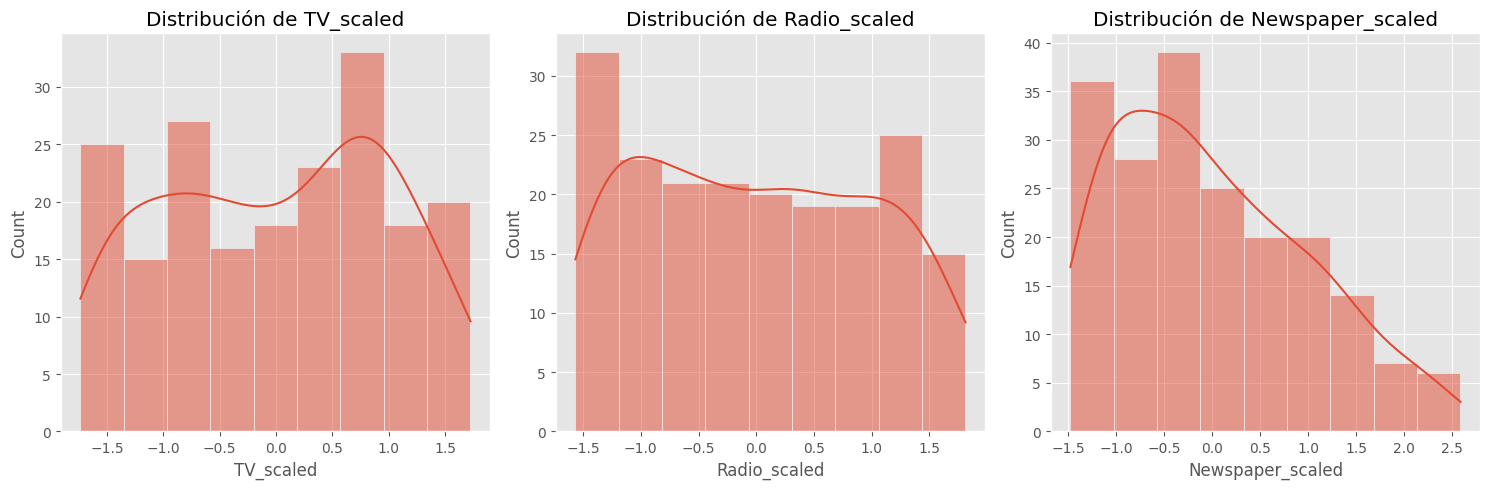

In [5]:
from sklearn.preprocessing import StandardScaler

# Escalamiento de datos
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean.drop('Sales', axis=1))
df_scaled = pd.DataFrame(scaled_data, columns=['TV_scaled', 'Radio_scaled', 'Newspaper_scaled'])
df_scaled['Sales'] = df_clean['Sales'].values

# Mostrar datos escalados
print("\nPrimeras filas de datos escalados:")
print(df_scaled.head())

# Visualizar distribución después del escalamiento
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, column in enumerate(['TV_scaled', 'Radio_scaled', 'Newspaper_scaled']):
    ax = axes[i]
    sns.histplot(df_scaled[column], kde=True, ax=ax)
    ax.set_title(f'Distribución de {column}')
plt.tight_layout()
plt.show()

In [7]:
pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 5.3 MB/s eta 0:00:00


In [8]:
from deap import base, creator, tools, algorithms
import random
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Preparar datos para el algoritmo genético
X = df_scaled.drop('Sales', axis=1).values
y = df_scaled['Sales'].values

# Configurar el problema de optimización
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Generación de individuos (combinaciones de variables)
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=3)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Función de evaluación (R2 score)
def eval_r2(individual):
    # Seleccionar variables según el individuo
    mask = np.array(individual, dtype=bool)
    if not any(mask):  # Si no hay ninguna variable seleccionada
        return 0.0,  # Tupla con coma para ser compatible

    X_selected = X[:, mask]

    # Dividir en train y test
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

    # Entrenar modelo y calcular R2
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    return r2,

toolbox.register("evaluate", eval_r2)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# Parámetros del algoritmo genético
population_size = 50
crossover_prob = 0.8
mutation_prob = 0.2
num_generations = 20

# Estadísticas para seguir la evolución
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)
stats.register("max", np.max)

# Ejecutar el algoritmo genético
population = toolbox.population(n=population_size)
hof = tools.HallOfFame(1)  # Guardar el mejor individuo

print("\nIniciando algoritmo genético...")
population, logbook = algorithms.eaSimple(population, toolbox, cxpb=crossover_prob,
                                         mutpb=mutation_prob, ngen=num_generations,
                                         stats=stats, halloffame=hof, verbose=True)


Iniciando algoritmo genético...
gen	nevals	avg     	min	max     
0  	50    	0.495833	0  	0.898764
1  	43    	0.793231	0  	0.898764
2  	45    	0.889993	0.479433	0.898764
3  	42    	0.882568	0.439087	0.898764
4  	44    	0.898764	0.898764	0.898764
5  	48    	0.89874 	0.897564	0.898764
6  	40    	0.898764	0.898764	0.898764
7  	44    	0.898692	0.897564	0.898764
8  	42    	0.891857	0.553452	0.898764
9  	37    	0.889546	0.439087	0.898764
10 	47    	0.898764	0.898764	0.898764
11 	39    	0.871159	0.439087	0.898764
12 	39    	0.889546	0.439087	0.898764
13 	43    	0.898764	0.898764	0.898764
14 	45    	0.889546	0.439087	0.898764
15 	41    	0.88957 	0.439087	0.898764
16 	47    	0.898716	0.897564	0.898764
17 	41    	0.889546	0.439087	0.898764
18 	31    	0.898764	0.898764	0.898764
19 	41    	0.866564	0.439087	0.898764
20 	44    	0.882664	0.439087	0.898764


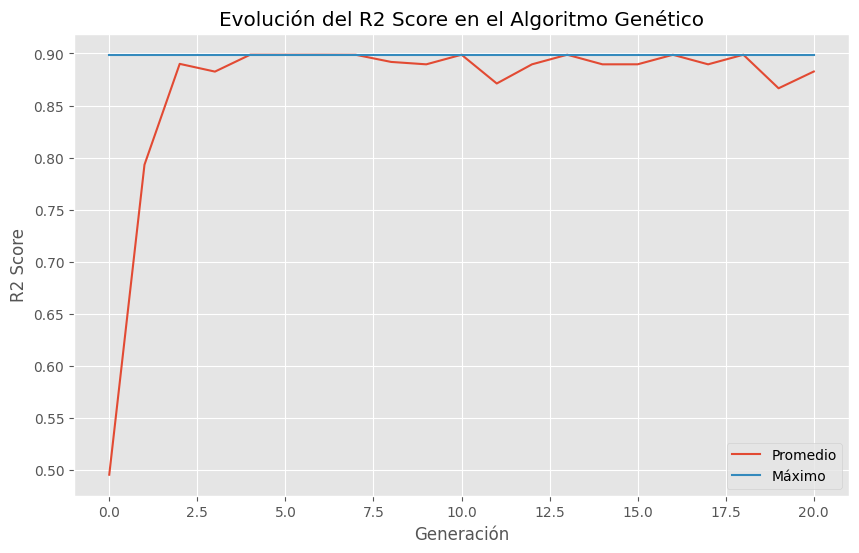


Mejores variables seleccionadas: ['TV_scaled', 'Radio_scaled', 'Newspaper_scaled']

R2 Score en conjunto de prueba: 0.8988

Coeficientes del modelo:
TV_scaled: 3.8728
Radio_scaled: 2.7631
Newspaper_scaled: 0.1085
Intercepto: 14.0482


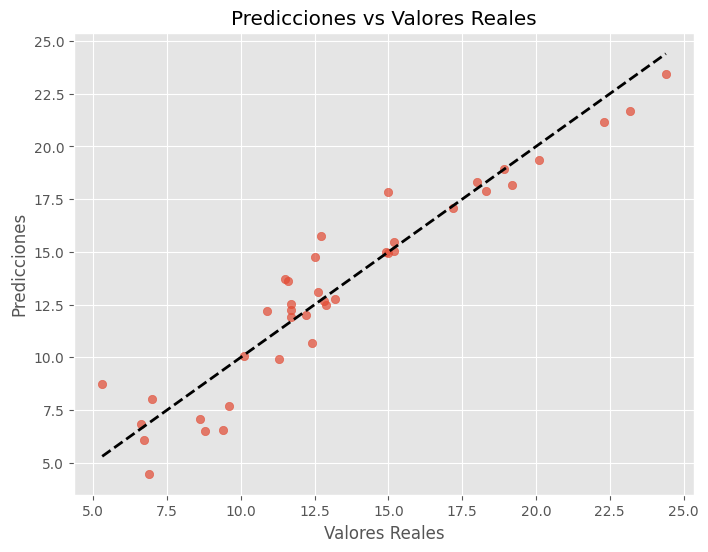

In [9]:
# Extraer datos de evolución
gen = logbook.select("gen")
avg = logbook.select("avg")
max_ = logbook.select("max")

# Graficar evolución
plt.figure(figsize=(10, 6))
plt.plot(gen, avg, label="Promedio")
plt.plot(gen, max_, label="Máximo")
plt.xlabel("Generación")
plt.ylabel("R2 Score")
plt.title("Evolución del R2 Score en el Algoritmo Genético")
plt.legend()
plt.grid(True)
plt.show()

# Mostrar mejor combinación de variables
best_individual = hof[0]
selected_vars = [df_scaled.columns[i] for i in range(3) if best_individual[i]]
print("\nMejores variables seleccionadas:", selected_vars)

# Entrenar modelo final con las mejores variables
mask = np.array(best_individual, dtype=bool)
X_selected = X[:, mask]

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Evaluar modelo
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"\nR2 Score en conjunto de prueba: {r2:.4f}")

# Mostrar coeficientes del modelo
print("\nCoeficientes del modelo:")
for var, coef in zip(selected_vars, model.coef_):
    print(f"{var}: {coef:.4f}")
print(f"Intercepto: {model.intercept_:.4f}")

# Visualización de resultados
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.grid(True)
plt.show()